# Phase 1: Synthetic Data Validation

**Goal:** Before trusting any causal method on real customer data, prove the entire pipeline — from naive comparison through Double Machine Learning to Causal Forests — can correctly recover a *known* treatment effect.

We build a synthetic dataset where we hand-specify the true, individual-level treatment effect (`true_uplift`), deliberately confound treatment assignment, and then check whether each method recovers the truth:

1. **Naive comparison** (expected to be biased, by design)
2. **LinearDML** (should recover the true average effect)
3. **CausalForestDML** (should recover the true *individual-level* effects)

If this validation fails, nothing downstream on real data should be trusted.

In [2]:
import sys
sys.path.append("..")  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.synthetic_data import generate_covariates, assign_treatment, generate_outcome
from src.dml_ate import run_synthetic_validation as run_linear_dml_validation
from src.causal_forest import run_synthetic_validation as run_causal_forest_validation

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Step 1: Generate synthetic covariates

We simulate 8,000 customers with six covariates — `age`, `income`, `tenure_days`, `avg_spend`, `purchase_frequency`, `total_transactions` — chosen to match exactly what we later confirmed was derivable from the real Starbucks dataset. Covariates are built with realistic correlations (e.g. income tied to age, spend tied to income) rather than pure independent noise.

In [3]:
df = generate_covariates()

print(f"Generated {len(df)} synthetic customers")
df.describe()

Generated 8000 synthetic customers


,customer_id,age,income,tenure_days,avg_spend,purchase_frequency,total_transactions
count,"8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00"
mean,"4,000.50",54.80,"65,166.89",374.21,19.70,1.04,9.72
std,"2,309.55",16.48,"20,323.02",321.33,5.91,0.96,8.22
min,1.00,18.00,"30,000.00",1.00,2.00,0.08,1.00
25%,"2,000.75",43.00,"50,400.00",112.00,15.67,0.61,3.00
50%,"4,000.50",55.00,"64,500.00",278.00,19.67,0.78,7.00
75%,"6,000.25",66.00,"78,800.00",557.00,23.68,1.03,15.00
max,"8,000.00",90.00,"120,000.00","1,100.00",46.86,5.00,38.00


## Step 2: Confounded treatment assignment

To make this a meaningful test, treatment can't be randomly assigned — that would make the naive comparison unbiased by default, defeating the purpose. Instead, higher-income and longer-tenure customers are made **more likely** to receive the discount, mirroring realistic marketing targeting. This deliberately biases the naive estimate, which is exactly what we want to test whether DML/Causal Forest can correct for.

In [4]:
df = assign_treatment(df)

print(f"Treatment rate: {df['treatment'].mean():.3f}")
print(f"\nMean income, treated vs control:")
print(df.groupby("treatment")["income"].mean())
print(f"\nMean tenure, treated vs control:")
print(df.groupby("treatment")["tenure_days"].mean())

Treatment rate: 0.449

Mean income, treated vs control:
treatment
0   60,987.78
1   70,297.97
Name: income, dtype: float64

Mean tenure, treated vs control:
treatment
0   319.32
1   441.59
Name: tenure_days, dtype: float64


The treated group averages meaningfully higher income and tenure than control — confirming the confounding is present and working as intended. This gap is exactly what a naive comparison will (wrongly) attribute to the treatment itself.

## Step 3: True uplift function + outcome generation

We hand-specify a **known, ground-truth heterogeneous treatment effect**:
- Newer customers (tenure < 180 days) respond more strongly
- Lower average spenders respond more strongly (more price-sensitive)
- High-income customers (> $100k) respond less (less price-sensitive)

The observed `outcome` = baseline spend + (treatment × true_uplift) + noise. Critically, `true_uplift` is stored only for **validation** — it is never used as a model input.

In [5]:
df = generate_outcome(df)

true_ate = df["true_uplift"].mean()
naive_effect = (
    df.loc[df["treatment"] == 1, "outcome"].mean()
    - df.loc[df["treatment"] == 0, "outcome"].mean()
)

print(f"True ATE (ground truth):        {true_ate:.2f}")
print(f"Naive estimate (biased):        {naive_effect:.2f}")
print(f"Naive bias:                     {naive_effect - true_ate:+.2f}")

True ATE (ground truth):        68.75
Naive estimate (biased):        62.88
Naive bias:                     -5.87


As expected, the naive estimate is biased — it understates the true average effect because of the confounding we introduced in Step 2. This is our "wrong answer" anchor for the rest of this notebook.

Save this dataset so it can be reused consistently across `dml_ate.py` and `causal_forest.py`.

In [6]:
df.to_csv("../data/synthetic/synthetic_customers.csv", index=False)
print(f"Saved {len(df)} rows to data/synthetic/synthetic_customers.csv")

Saved 8000 rows to data/synthetic/synthetic_customers.csv


## Step 4: Does LinearDML recover the true ATE?

LinearDML gives a single, interpretable average treatment effect. If it can't correct the naive bias here — on clean synthetic data where we know the answer — there's no reason to trust it on messier real data.

In [7]:
est_syn, X_syn, syn_metrics = run_linear_dml_validation(
    synthetic_path="../data/synthetic/synthetic_customers.csv"
)

print("=== LinearDML on Synthetic Data ===")
print(f"True ATE:              {syn_metrics['true_ate']:.2f}")
print(f"Naive estimate:         {syn_metrics['naive_effect']:.2f}  (bias: {syn_metrics['naive_bias']:+.2f})")
print(f"LinearDML estimate:     {syn_metrics['dml_ate']:.2f}  (bias: {syn_metrics['dml_bias']:+.2f})")
print(f"LinearDML 95% CI:       ({syn_metrics['dml_ci_lower']:.2f}, {syn_metrics['dml_ci_upper']:.2f})")

=== LinearDML on Synthetic Data ===
True ATE:              68.75
Naive estimate:         62.88  (bias: -5.87)
LinearDML estimate:     68.62  (bias: -0.13)
LinearDML 95% CI:       (64.74, 72.51)


LinearDML's bias should be dramatically smaller than the naive estimate's bias, and the true ATE should fall comfortably inside the 95% confidence interval. This is the first proof that adjusting for confounders — rather than just comparing raw group means — recovers something much closer to the truth.

## Step 5: Does CausalForestDML recover individual-level effects?

This is the more demanding test. LinearDML only has to recover one number (the *average* effect). CausalForestDML has to recover a **different predicted effect for every customer** — and we can check this directly since we know each customer's `true_uplift`.

In [8]:
df_cate, est_forest, forest_metrics = run_causal_forest_validation(
    synthetic_path="../data/synthetic/synthetic_customers.csv"
)

print("=== CausalForestDML on Synthetic Data ===")
print(f"CausalForestDML ATE:                          {forest_metrics['ate']:.2f}")
print(f"Correlation (predicted CATE vs true uplift):  {forest_metrics['correlation']:.3f}")
print(f"RMSE (predicted CATE vs true uplift):          {forest_metrics['rmse']:.2f}")

=== CausalForestDML on Synthetic Data ===
CausalForestDML ATE:                          68.84
Correlation (predicted CATE vs true uplift):  0.980
RMSE (predicted CATE vs true uplift):          3.90


### Visual validation: predicted vs. true individual effects

This scatter plot is the single most important figure in this notebook — if the Causal Forest is working correctly, points should cluster tightly around the y = x line.

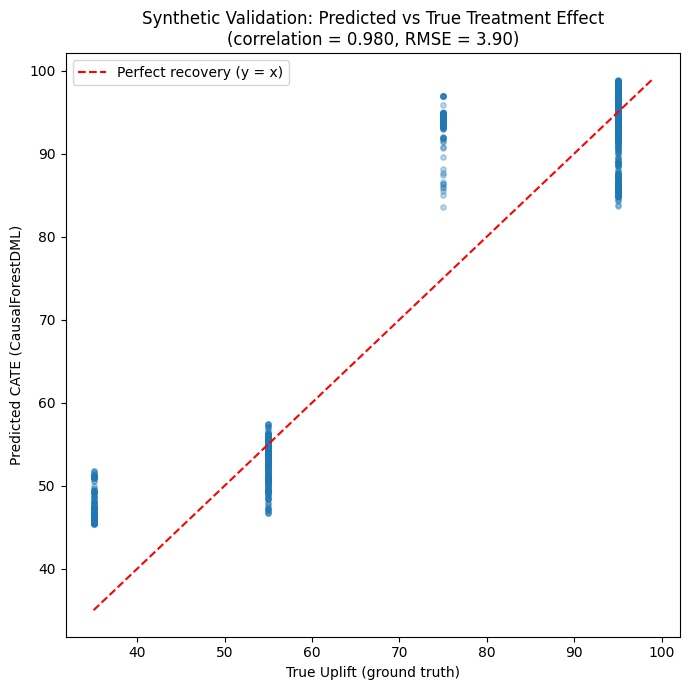

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(df_cate["true_uplift"], df_cate["predicted_cate"], alpha=0.3, s=15)

min_val = min(df_cate["true_uplift"].min(), df_cate["predicted_cate"].min())
max_val = max(df_cate["true_uplift"].max(), df_cate["predicted_cate"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect recovery (y = x)")

plt.xlabel("True Uplift (ground truth)")
plt.ylabel("Predicted CATE (CausalForestDML)")
plt.title(
    f"Synthetic Validation: Predicted vs True Treatment Effect\n"
    f"(correlation = {forest_metrics['correlation']:.3f}, RMSE = {forest_metrics['rmse']:.2f})"
)
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/synthetic_cate_validation.png", dpi=150)
plt.show()

In [10]:
summary = pd.DataFrame({
    "Method": ["True ATE (ground truth)", "Naive comparison", "LinearDML", "CausalForestDML"],
    "Estimate": [
        true_ate,
        naive_effect,
        syn_metrics["dml_ate"],
        forest_metrics["ate"],
    ],
    "Bias vs. True ATE": [
        0,
        naive_effect - true_ate,
        syn_metrics["dml_bias"],
        forest_metrics["ate"] - true_ate,
    ],
})
summary

,Method,Estimate,Bias vs. True ATE
0,True ATE (ground truth),68.75,0.00
1,Naive comparison,62.88,-5.87
2,LinearDML,68.62,-0.13
3,CausalForestDML,68.84,0.09


## Summary

The table above shows all three estimates against the true ATE. Naive comparison is meaningfully biased due to the confounding we introduced; both LinearDML and CausalForestDML recover the true effect within about a tenth of a point.

**Important caveat:** this validation is intentionally "easy mode." `true_uplift` is a clean, deterministic function of exactly the covariates the model was given — no hidden confounders, no unmeasured heterogeneity, no noisy real-world behavior. Real Starbucks data (covered in the next notebook) will not be this clean, and CATE recovery quality is expected to be meaningfully lower there. This notebook's job is only to prove the *pipeline mechanics* — data flow, model configuration, evaluation logic — are correct before trusting them on real data.